# Züri wie neu - Spatial Analysis of Urban Infrastructure Reports in Zurich

## 1. Project Overview
This project analyses reported infrastructure issues in Zurich between 2014 and 2025 using open data from the "Züri wie neu" platform, statistical neighbourhood boundaries, and neighbourhood population data.

### 1.1. Data sources
The analysis is based on open geospatial datasets provided by the City of Zurich:

- Züri wie neu reports
  https://data.stadt-zuerich.ch/dataset/geo_zueri_wie_neu

- Statistical neighbourhoods
  https://data.stadt-zuerich.ch/dataset/geo_statistische_quartiere

- Population by neighbourhood
  https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_quartier_od3240

The reports and statistical neighbourhoods datasets were downloaded on 04.05.2026.

The population by neighbourhood dataset was downloaded on 12.05.2026

### 1.2. Research Question 
How are reported infrastructure problems distributed across the neighbourhoods of Zurich in 2025 and what temporal reporting patterns can be observed between 2014 and 2025?

### 1.3. Subquestions
1. Which neighbourhoods have the highest number of infrastructure reports in 2025?
2. Which problem categories are most common in 2025?
3. Are certain problem categories concentrated in specific neighbourhoods in 2025?
4. How have infrastructure reports changed between 2014 and 2025 and are there seasonal patterns?

## 2. Load the data

In [58]:
# import libraries
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

reports = gpd.read_file("../data/raw/Zueri_wie_neu.gpkg")

neighbourhoods = gpd.read_file("../data/raw/Statistische_Quartiere.gpkg",layer="stzh.adm_statistische_quartiere_v")

population_zh = pd.read_csv("../data/raw/bev324od3240.csv")

## 3. Data Inspection
Before starting the analysis, the structure, columns, coordinate reference system and missing values of both datasets are inspected.

### 3.1. Inspect reports dataset

In [59]:
# check first five rows of dataset
reports.head()

,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry
0,1,1,2013-03-14 15:16:15,2013-04-04 07:25:05,2013-04-12 07:59:30,2678968,1247548,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Asp,Auf dem Asphalt des Bürgersteigs hat es eine E...,,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,POINT (2678968 1247548)
1,2,2,2013-03-14 15:17:57,2013-03-26 14:05:05,2013-04-12 08:00:22,2680746,1249916,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Vermessungs,Vermessungspunkt ist nicht mehr bündig mit dem...,,Web interface,Diese Reparatur wird von uns in den kommenden ...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,POINT (2680746 1249916)
2,3,4,2013-03-15 09:14:16,2013-03-15 09:55:05,2013-04-12 08:08:10,2684605,1251431,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Beim Trotto,Beim Trottoir sind einige Randsteine defekt un...,https://www.zueriwieneu.ch/photo/4.0.jpeg?bfbb...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,POINT (2684605 1251431)
3,4,5,2013-03-15 09:17:15,2013-03-20 10:05:05,2013-04-12 08:09:05,2681754,1250376,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Par,Auf dem Parkplatz beim Waidspital sind einige ...,https://www.zueriwieneu.ch/photo/5.0.jpeg?e309...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Par: Auf dem Parkplatz beim Waidspital...,https://www.zueriwieneu.ch/report/5,POINT (2681754 1250376)
4,5,6,2013-03-15 10:36:53,2013-04-22 18:25:05,2013-04-23 13:50:33,2683094,1247762,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,16624,Arbeitskist,Arbeitskiste ist rund herum verschmiert,https://www.zueriwieneu.ch/photo/6.0.jpeg?8e65...,Web interface,Dieses Graffiti wird von uns in den kommenden ...,Arbeitskist: Arbeitskiste ist rund herum versc...,https://www.zueriwieneu.ch/report/6,POINT (2683094 1247762)


In [60]:
# check how many rows and columns
reports.shape

(72623, 19)

In [61]:
# check column names
reports.columns

Index(['objectid', 'service_request_id', 'requested_datetime',
       'agency_sent_datetime', 'updated_datetime', 'e', 'n', 'service_code',
       'service_name', 'status', 'userid', 'title', 'detail', 'media_url',
       'interface_used', 'service_notice', 'description', 'url', 'geometry'],
      dtype='object')

In [62]:
# check coordinate system
reports.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

In [63]:
# check dataset structure and data types
reports.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 72623 entries, 0 to 72622
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   objectid              72623 non-null  int32         
 1   service_request_id    72623 non-null  object        
 2   requested_datetime    72623 non-null  datetime64[ms]
 3   agency_sent_datetime  71802 non-null  datetime64[ms]
 4   updated_datetime      72623 non-null  datetime64[ms]
 5   e                     72623 non-null  int32         
 6   n                     72623 non-null  int32         
 7   service_code          72623 non-null  object        
 8   service_name          72623 non-null  object        
 9   status                72623 non-null  object        
 10  userid                72623 non-null  int32         
 11  title                 72623 non-null  object        
 12  detail                72623 non-null  object        
 13  media_ur

In [64]:
# check for missing values
reports.isna().sum()

objectid                  0
service_request_id        0
requested_datetime        0
agency_sent_datetime    821
updated_datetime          0
e                         0
n                         0
service_code              0
service_name              0
status                    0
userid                    0
title                     0
detail                    0
media_url                 0
interface_used            0
service_notice            0
description               0
url                       0
geometry                  0
dtype: int64

The reports dataset contains point geometries representing reported infrastructure problems across Zurich. It includes information about report dates, problem categories, status information and spatial coordinates. The dataset consists of 72'623 reports and 19 variables. Only a small number of missing values were identified in the `agency_sent_datetime` column. The coordinate reference system is EPSG:2056 (CH1903+ / LV95), which is suitable for spatial analysis in Switzerland.

### 3.2. Inspect neighbourhood dataset

In [65]:
# check first five rows of dataset
neighbourhoods.head()

,objid,objectid,qname,qnr,kname,knr,geometry
0,1,1,Alt-Wiedikon,31,Kreis 3,3,"POLYGON ((2680606.662 1247034.584, 2680626.356..."
1,10,2,Witikon,74,Kreis 7,7,"POLYGON ((2685858.632 1246502.629, 2685860.738..."
2,11,3,Langstrasse,42,Kreis 4,4,"POLYGON ((2681313.304 1248613.857, 2681459.605..."
3,12,4,Escher Wyss,52,Kreis 5,5,"POLYGON ((2680009.144 1249565.021, 2680055.843..."
4,13,5,Enge,24,Kreis 2,2,"POLYGON ((2681898.171 1246379.668, 2681899.115..."


In [66]:
# check how many rows and columns
neighbourhoods.shape

(34, 7)

In [67]:
# check column names
neighbourhoods.columns

Index(['objid', 'objectid', 'qname', 'qnr', 'kname', 'knr', 'geometry'], dtype='object')

In [68]:
# check coordinate system
neighbourhoods.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

In [69]:
# check dataset structure and data types
neighbourhoods.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   objid     34 non-null     object  
 1   objectid  34 non-null     int32   
 2   qname     34 non-null     object  
 3   qnr       34 non-null     int32   
 4   kname     34 non-null     object  
 5   knr       34 non-null     int32   
 6   geometry  34 non-null     geometry
dtypes: geometry(1), int32(3), object(3)
memory usage: 1.6+ KB


In [70]:
# check for missing values
neighbourhoods.isna().sum()

objid       0
objectid    0
qname       0
qnr         0
kname       0
knr         0
geometry    0
dtype: int64

The neighbourhood dataset contains polygon geometries representing the statistical neighbourhoods of Zurich. It consists of 34 neighbourhood polygons and 7 variables, including neighbourhood names and district identifiers. No missing values were detected in the dataset. The dataset is also stored in EPSG:2056 (CH1903+ / LV95), ensuring compatibility for spatial analysis and spatial joins with the reports dataset.

### 3.3. Inspect population dataset

In [71]:
# check first five rows of dataset
population_zh.head()

,StichtagDatJahr,QuarSort,QuarLang,AnzBestWir
0,2025,11,Rathaus,3252
1,2024,11,Rathaus,3260
2,2023,11,Rathaus,3343
3,2022,11,Rathaus,3330
4,2021,11,Rathaus,3275


In [72]:
# check how many rows and columns
population_zh.shape

(2785, 4)

In [73]:
# check column names
population_zh.columns

Index(['StichtagDatJahr', 'QuarSort', 'QuarLang', 'AnzBestWir'], dtype='object')

In [74]:
# check dataset structure and data types
population_zh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2785 entries, 0 to 2784
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   StichtagDatJahr  2785 non-null   int64 
 1   QuarSort         2785 non-null   int64 
 2   QuarLang         2785 non-null   object
 3   AnzBestWir       2785 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 87.2+ KB


In [75]:
# check for missing values
population_zh.isna().sum()

StichtagDatJahr    0
QuarSort           0
QuarLang           0
AnzBestWir         0
dtype: int64

The population dataset contains yearly population counts for the statistical neighbourhoods of Zurich. It consists of 2'785 entries and 4 variables, including neighbourhood identifiers and total resident counts. No missing values were detected in the dataset. The population data is used to calculate population-normalised reporting rates and compare report intensity between neighbourhoods independent of population size.

## 4. Data Cleaning and Preparation
The datasets are prepared by converting datetime columns, creating temporal variables, and selecting only the variables relevant for the analysis.
### 4.1. Convert datetime columns

In [76]:
reports["requested_datetime"] = pd.to_datetime(reports["requested_datetime"])
reports["updated_datetime"] = pd.to_datetime(reports["updated_datetime"])

### 4.2. Create temporal variables
Additional temporal variables are created from the original datetime column. These variables allow the analysis of trends and seasonal patterns over time.

In [77]:
reports["year"] = reports["requested_datetime"].dt.year
reports["month"] = reports["requested_datetime"].dt.month
reports["weekday"] = reports["requested_datetime"].dt.day_name()

The new temporal variables allow the analysis of yearly trends, monthly patterns and weekday reporting behaviour.

### 4.3. Clean reports dataset

In [84]:
# check number of reports by year
reports["year"].value_counts().sort_index()

year
2013     2901
2014     2139
2015     1943
2016     2307
2017     2869
2018     3724
2019     5243
2020     4802
2021     5783
2022     6828
2023     8325
2024    10794
2025    11588
2026     3377
Name: count, dtype: int64

Only relevant variables are kept for the analysis in order to simplify the workflow and improve readability.

For the temporal trend analysis, only complete years between 2014 and 2025 are retained. The years 2013 and 2026 are excluded because they do not contain a full year of observations.

The year 2025 is used for the detailed spatial and seasonal analyses because it contains the highest number of reports and represents a complete reporting year in the dataset.

In [83]:
# select for relevant variables
reports_relevant_var = reports[[
    "requested_datetime",
    "updated_datetime",
    "service_name",
    "status",
    "description",
    "year",
    "month",
    "weekday",
    "geometry"
]]

# filter complete years (2014-2025)
reports_clean = reports_relevant_var[
    (reports_relevant_var["year"] >= 2014) &
    (reports_relevant_var["year"] <= 2025)
]

# filter reports for 2025
reports_2025 = reports_clean[reports_clean["year"] == 2025]

### 4.4. Clean neighbourhood dataset
Only the neighbourhood name, district name, and geometry are required for the spatial analysis.

In [85]:
# select relevant variables
neighbourhoods_clean = neighbourhoods[[
    "qname",
    "kname",
    "geometry"
]]

### 4.5. Clean population dataset
The population dataset is filtered for the year 2025. This allows the report counts from 2025 to be compared with population data from the same year.

In [92]:
# rename population columns
population_zh = population_zh.rename(columns={
    "StichtagDatJahr": "year",
    "QuarLang": "qname",
    "AnzBestWir": "population"
})

# filter population data for 2025
population_zh_2025 = population_zh[population_zh["year"] == 2025]

# select relevant variables
population_zh_2025_clean = population_zh_2025[[
    "qname",
    "population"
]]

### 4.6. Check cleaned data

The cleaned datasets are inspected to confirm that only the relevant variables required for the analysis are retained.

In [93]:
# check first five rows of dataset
reports_clean.head()

,requested_datetime,updated_datetime,service_name,status,description,year,month,weekday,geometry
188,2014-05-13 07:33:00,2014-05-13 14:10:04,Strasse/Trottoir/Platz,external,Hydrant ang: Hydrant angefahren,2014,5,Tuesday,POINT (2682906 1248393)
709,2014-02-11 01:22:49,2014-02-12 08:55:04,Graffiti,external,Graffiti an: Graffiti an Mauer unterhalb Althe...,2014,2,Tuesday,POINT (2684062 1249961)
771,2014-08-20 14:49:16,2014-08-20 15:00:05,Strasse/Trottoir/Platz,external,S tropft!: S tropft!,2014,8,Wednesday,POINT (2680531 1249514)
1023,2014-02-15 19:58:01,2014-02-17 12:56:33,Beleuchtung/Uhren,fixed - council,Strassenlam: Strassenlampe defekt,2014,2,Saturday,POINT (2681133 1250273)
1509,2016-06-27 14:31:04,2016-07-01 07:58:40,Brunnen/Hydranten,fixed - council,Brunnen übe: Brunnen überläuft,2016,6,Monday,POINT (2683920 1245604)


In [94]:
# check first five rows of dataset
reports_2025.head()

,requested_datetime,updated_datetime,service_name,status,description,year,month,weekday,geometry
44670,2025-06-16 20:06:53,2025-06-17 07:07:04,Abfall/Sammelstelle,external,Veloschrott: Veloschrott,2025,6,Monday,POINT (2682447 1247655)
45845,2025-05-12 10:05:31,2025-05-12 10:12:05,Abfall/Sammelstelle,external,Demoliertes: Demoliertes Velo,2025,5,Monday,POINT (2681227 1248047)
45867,2025-05-22 19:41:18,2025-05-26 05:42:43,Beleuchtung/Uhren,fixed - council,Lampe kaput: Lampe kaputt,2025,5,Thursday,POINT (2682870 1247836)
45975,2025-06-29 18:24:09,2025-06-30 12:12:04,Abfall/Sammelstelle,external,Ausgeschlac: Ausgeschlachteter Scooter,2025,6,Sunday,POINT (2681519 1247334)
46705,2025-02-16 22:19:45,2025-04-03 10:26:13,Graffiti,fixed - council,Graffiti: Graffiti,2025,2,Sunday,POINT (2683763 1247000)


In [95]:
# check first five rows of dataset
neighbourhoods_clean.head()

,qname,kname,geometry
0,Alt-Wiedikon,Kreis 3,"POLYGON ((2680606.662 1247034.584, 2680626.356..."
1,Witikon,Kreis 7,"POLYGON ((2685858.632 1246502.629, 2685860.738..."
2,Langstrasse,Kreis 4,"POLYGON ((2681313.304 1248613.857, 2681459.605..."
3,Escher Wyss,Kreis 5,"POLYGON ((2680009.144 1249565.021, 2680055.843..."
4,Enge,Kreis 2,"POLYGON ((2681898.171 1246379.668, 2681899.115..."


In [96]:
# check first five rows of dataset
population_zh_2025_clean.head()

,qname,population
0,Rathaus,3252
85,Hochschulen,688
170,Lindenhof,1038
255,City,769
340,Wollishofen,22029


## 5. Spatial Join
A spatial join is used to assign each report point to the neighbourhood polygon in which it is located.

In [97]:
reports_with_neighbourhoods = gpd.sjoin(reports_2025,neighbourhoods_clean,how="left",predicate="within")

In [98]:
reports_with_neighbourhoods.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 11588 entries, 44670 to 69270
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   requested_datetime  11588 non-null  datetime64[ms]
 1   updated_datetime    11588 non-null  datetime64[ms]
 2   service_name        11588 non-null  object        
 3   status              11588 non-null  object        
 4   description         11588 non-null  object        
 5   year                11588 non-null  int32         
 6   month               11588 non-null  int32         
 7   weekday             11588 non-null  object        
 8   geometry            11588 non-null  geometry      
 9   index_right         11588 non-null  int64         
 10  qname               11588 non-null  object        
 11  kname               11588 non-null  object        
dtypes: datetime64[ms](2), geometry(1), int32(2), int64(1), object(6)
memory usage: 1.1+ MB


In [99]:
reports_with_neighbourhoods.head()

,requested_datetime,updated_datetime,service_name,status,description,year,month,weekday,geometry,index_right,qname,kname
44670,2025-06-16 20:06:53,2025-06-17 07:07:04,Abfall/Sammelstelle,external,Veloschrott: Veloschrott,2025,6,Monday,POINT (2682447 1247655),2,Langstrasse,Kreis 4
45845,2025-05-12 10:05:31,2025-05-12 10:12:05,Abfall/Sammelstelle,external,Demoliertes: Demoliertes Velo,2025,5,Monday,POINT (2681227 1248047),29,Hard,Kreis 4
45867,2025-05-22 19:41:18,2025-05-26 05:42:43,Beleuchtung/Uhren,fixed - council,Lampe kaput: Lampe kaputt,2025,5,Thursday,POINT (2682870 1247836),15,City,Kreis 1
45975,2025-06-29 18:24:09,2025-06-30 12:12:04,Abfall/Sammelstelle,external,Ausgeschlac: Ausgeschlachteter Scooter,2025,6,Sunday,POINT (2681519 1247334),17,Sihlfeld,Kreis 3
46705,2025-02-16 22:19:45,2025-04-03 10:26:13,Graffiti,fixed - council,Graffiti: Graffiti,2025,2,Sunday,POINT (2683763 1247000),30,Hochschulen,Kreis 1


The spatial join assigns each report point from 2025 to the neighbourhood polygon in which it is located.
### 5.1. Export processed dataset
The cleaned and spatially joined dataset is exported to the processed folder so it can be reused in future analyses or shared with others.


In [105]:
# export spatially joined dataset
reports_with_neighbourhoods.to_file(
    "../data/processed/reports_with_neighbourhoods_2025.gpkg",
    driver="GPKG"
)

## 6. Spatial analysis
### 6.1. Reports per neighbourhood
This section answers the question of which neighbourhoods have the highest number of reports in 2025. The reports are counted per neighbourhood and visualised as a choropleth map.

In [104]:
reports_per_neighbourhood = (reports_with_neighbourhoods
    .groupby("qname")
    .size()
    .reset_index(name="report_count")
)

### 6.2. Merge counts with neighbourhood polygons

In [101]:
neighbourhoods_merged = neighbourhoods_clean.merge(reports_per_neighbourhood, on="qname", how="left")

### 6.3. Check for the neighbourhoods with the highest number of reports

In [108]:
neighbourhoods_merged[[
    "qname",
    "kname",
    "report_count"
]].sort_values(
    by="report_count",
    ascending=False
).head()

,qname,kname,report_count
2,Langstrasse,Kreis 4,1200
17,Sihlfeld,Kreis 3,795
28,Altstetten,Kreis 9,628
21,Wipkingen,Kreis 10,528
23,Unterstrass,Kreis 6,517


### 6.4. Create reusable plotting function
To simplify the creation of multiple choropleth maps, a reusable plotting function is defined.

In [107]:
def create_choropleth(
    gdf,
    column,
    title,
    legend_title,
    output_path
):

    fig, ax = plt.subplots(figsize=(8, 8))

    gdf.plot(
        column=column,
        cmap="OrRd",
        scheme="NaturalBreaks",
        k=5,
        legend=True,
        edgecolor="black",
        ax=ax,
        legend_kwds={
            "title": legend_title,
            "loc": "lower right",
            "fmt": "{:.0f}"
        },
        missing_kwds={
            "color": "lightgrey",
            "label": "No data"
        }
    )

    # adjust legend labels
    legend = ax.get_legend()

    labels = [text.get_text() for text in legend.get_texts()]

    new_labels = [label.replace(",", " -") for label in labels]

    for text, label in zip(legend.get_texts(), new_labels):
        text.set_text(label)

    ax.set_title(title)
    ax.axis("off")

    # save figure
    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### 6.5. Choropleth map with absolute data
This choropleth map visualizes the absolute number of infrastructure reports per neighbourhood in 2025. 

The map uses Natural Breaks classification because it groups neighbourhoods with similar report counts. Five classes were chosen to balance detail and readability.

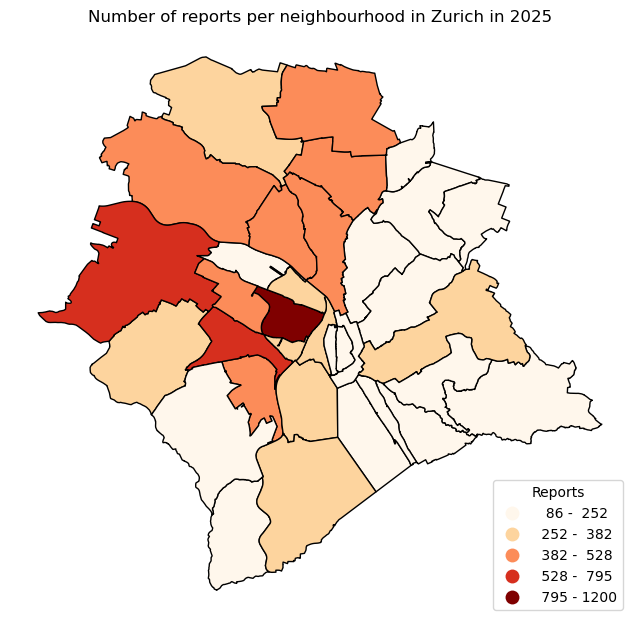

In [109]:
create_choropleth(
    neighbourhoods_merged,
    "report_count",
    "Number of reports per neighbourhood in Zurich in 2025",
    "Reports",
    "../outputs/maps/absolute_reports_zurich_2025 map.png"
)

The map shows clear spatial differences between neighbourhoods. The neighbourhood Langstrasse shows the highest number of reports in 2025. The darker red areas indicate higher report counts, while lighter colours represent fewer reports. Sihlfeld and Altstetten in the western part of the city also show relatively high numbers of reports. Medium and low report counts are more evenly distributed across the remaining neighbourhoods.

### 6.6. Reports normalised by population

Absolute report counts can be influenced by neighbourhood population size. Larger neighbourhoods may naturally contain more reports because more people live there.

Therefore, the number of reports is additionally normalised by population and expressed as reports per 1'000 residents. This allows a fairer comparison between neighbourhoods.

In [111]:
# merge neighbourhood report counts with population data
neighbourhoods_population = neighbourhoods_merged.merge(population_zh_2025_clean,on="qname",how="left")

# calculate reports per 1'000 residents
neighbourhoods_population["reports_per_1000"] = (
    neighbourhoods_population["report_count"] /
    neighbourhoods_population["population"] * 1000)

# check first five rows of normalised report dataset
neighbourhoods_population.head()

,qname,kname,geometry,report_count,population,reports_per_1000
0,Alt-Wiedikon,Kreis 3,"POLYGON ((2680606.662 1247034.584, 2680626.356...",456,18904,24.121879
1,Witikon,Kreis 7,"POLYGON ((2685858.632 1246502.629, 2685860.738...",170,11984,14.185581
2,Langstrasse,Kreis 4,"POLYGON ((2681313.304 1248613.857, 2681459.605...",1200,11978,100.183670
3,Escher Wyss,Kreis 5,"POLYGON ((2680009.144 1249565.021, 2680055.843...",212,6426,32.990974
4,Enge,Kreis 2,"POLYGON ((2681898.171 1246379.668, 2681899.115...",360,10015,35.946081


### 6.7. Check for the neighbourhoods with the highest number of population-normalised reports

In [113]:
neighbourhoods_population[[
    "qname",
    "kname",
    "reports_per_1000"
]].sort_values(
    by="reports_per_1000",
    ascending=False
).head()

,qname,kname,reports_per_1000
15,City,Kreis 1,374.512354
30,Hochschulen,Kreis 1,353.197674
24,Lindenhof,Kreis 1,199.421965
2,Langstrasse,Kreis 4,100.183670
13,Rathaus,Kreis 1,70.725707


### 6.6. Choropleth map with normalised data

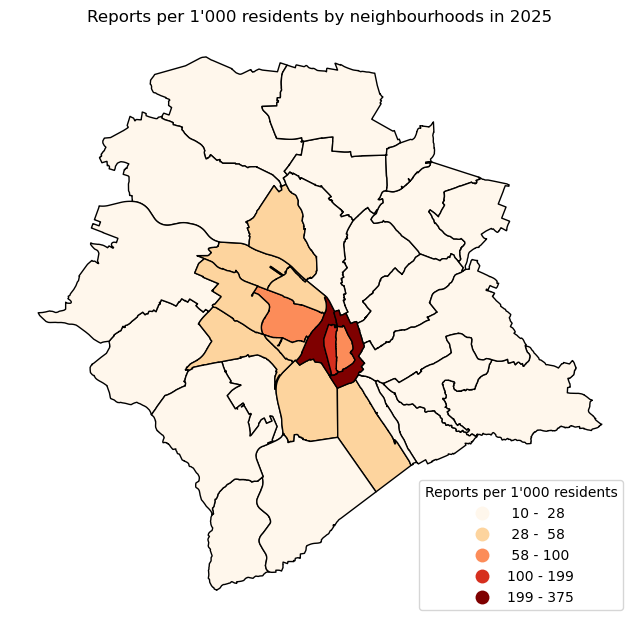

In [50]:
create_choropleth(
    neighbourhoods_population,
    "reports_per_1000",
    "Reports per 1'000 residents by neighbourhoods in 2025",
    "Reports per 1'000 residents",
    "../outputs/maps/reports_per_1000_zurich_2025.png"
)

The normalised map shows how report patterns change when neighbourhood population size is considered. Some neighbourhoods with high absolute report counts may appear less dominant after normalisation, while smaller neighbourhoods may show relatively high reporting rates.
After normalisation, City and Lindenhof have the highest number of reports per 1'000 residents. Higher reporting rates are mainly concentrated in central neighbourhoods, while outer neighbourhoods generally show lower values. 

### 6.7. Comparison of the absolute and normalised map
The side-by-side comparison highlights differences between absolute report counts and population-normalised reporting rates. This allows a better understanding of how neighbourhood size influences report patterns.

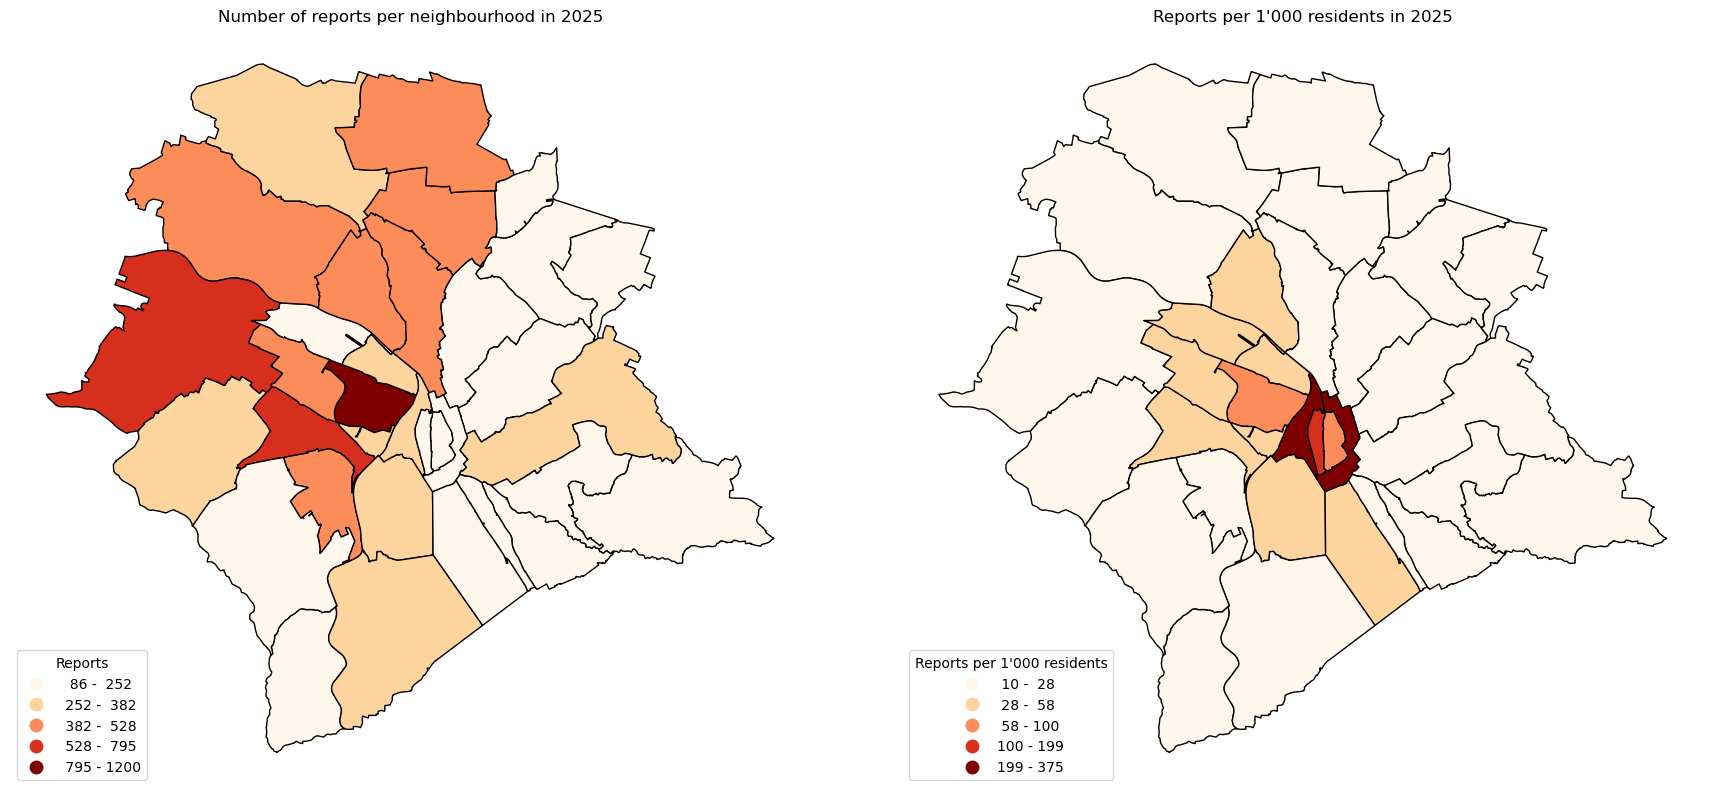

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# absolute reports
neighbourhoods_merged.plot(
    column="report_count",
    cmap="OrRd",
    scheme="NaturalBreaks",
    k=5,
    legend=True,
    edgecolor="black",
    ax=axes[0],
    legend_kwds={
        "title": "Reports",
        "loc": "lower left",
        "fmt": "{:.0f}"
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

axes[0].set_title("Number of reports per neighbourhood in 2025")
axes[0].axis("off")

# adjust legend labels
legend = axes[0].get_legend()

labels = [text.get_text() for text in legend.get_texts()]

new_labels = [label.replace(",", " -") for label in labels]

for text, label in zip(legend.get_texts(), new_labels):
    text.set_text(label)

# relative reports
neighbourhoods_population.plot(
    column="reports_per_1000",
    cmap="OrRd",
    scheme="NaturalBreaks",
    k=5,
    legend=True,
    edgecolor="black",
    ax=axes[1],
    legend_kwds={
        "title": "Reports per 1'000 residents",
        "loc": "lower left",
        "fmt": "{:.0f}"
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

axes[1].set_title("Reports per 1'000 residents in 2025")
axes[1].axis("off")

# adjust legend labels
legend = axes[1].get_legend()

labels = [text.get_text() for text in legend.get_texts()]

new_labels = [label.replace(",", " -") for label in labels]

for text, label in zip(legend.get_texts(), new_labels):
    text.set_text(label)

plt.tight_layout()

# save figure
fig.savefig(
    "../outputs/maps/comparison_map_zurich_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The comparison highlights clear differences between absolute and population-normalised report patterns. While western neighbourhoods show the highest absolute number of reports, the normalised map reveals that the highest reporting rates per 1'000 residents are concentrated in the city centre. 
## 7. Categorocal Analysis
This section analyses which types of infrastructure problems are most frequently reported in 2025. Report categories are counted and visualized with a bar chart to identify the most common types of reported issues.

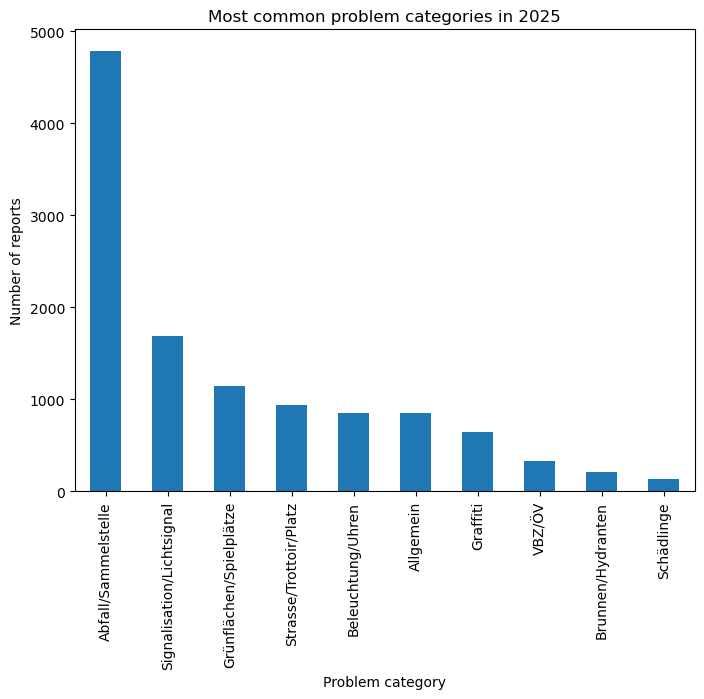

In [119]:
fig, ax = plt.subplots(figsize=(8, 6))

reports_2025["service_name"].value_counts().plot(
    kind="bar",
    ax=ax
)

ax.set_title("Most common problem categories in 2025")
ax.set_xlabel("Problem category")
ax.set_ylabel("Number of reports")

plt.xticks(rotation=90)

# save figure
fig.savefig(
    "../outputs/maps/most_common_problem_category_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The category distribution shows which types of problems dominate the Züri wie neu reports. This helps to understand the main types of infrastructure issues reported by residents.

The results show that Abfall/Sammelstelle is by far the most frequently reported problem category in 2025. Several other categories show moderate report numbers, while categories such as Brunnen/Hydranten and Schädlinge occur much less frequently.
## 8. Concentration of problem categories by neighbourhood
This section examines whether certain problem categories are concentrated in specific neighbourhoods.

In [120]:
# create cross-tabulation of problem categories by neighbourhood
category_by_neighbourhood = pd.crosstab(
    reports_with_neighbourhoods["qname"],
    reports_with_neighbourhoods["service_name"]
)

# check first five rows of cross-tabulation
category_by_neighbourhood.head()

service_name,Abfall/Sammelstelle,Allgemein,Beleuchtung/Uhren,Brunnen/Hydranten,Graffiti,Grünflächen/Spielplätze,Schädlinge,Signalisation/Lichtsignal,Strasse/Trottoir/Platz,VBZ/ÖV
qname,,,,,,,,,,
Affoltern,129,24,23,3,7,44,3,62,27,9
Albisrieden,122,15,24,11,11,40,7,84,42,4
Alt-Wiedikon,259,50,25,4,9,25,5,39,30,10
Altstetten,244,55,39,25,25,55,10,117,50,8
City,75,40,21,4,11,13,0,62,44,18


The cross-tabulation shows how often each problem category appears in each neighbourhood. This allows comparison of category patterns across Zurich.

The analysis focuses on selected problem categories that represent different types of urban infrastructure issues. This allows the identification of spatial concentration patterns across Zurich neighbourhoods.

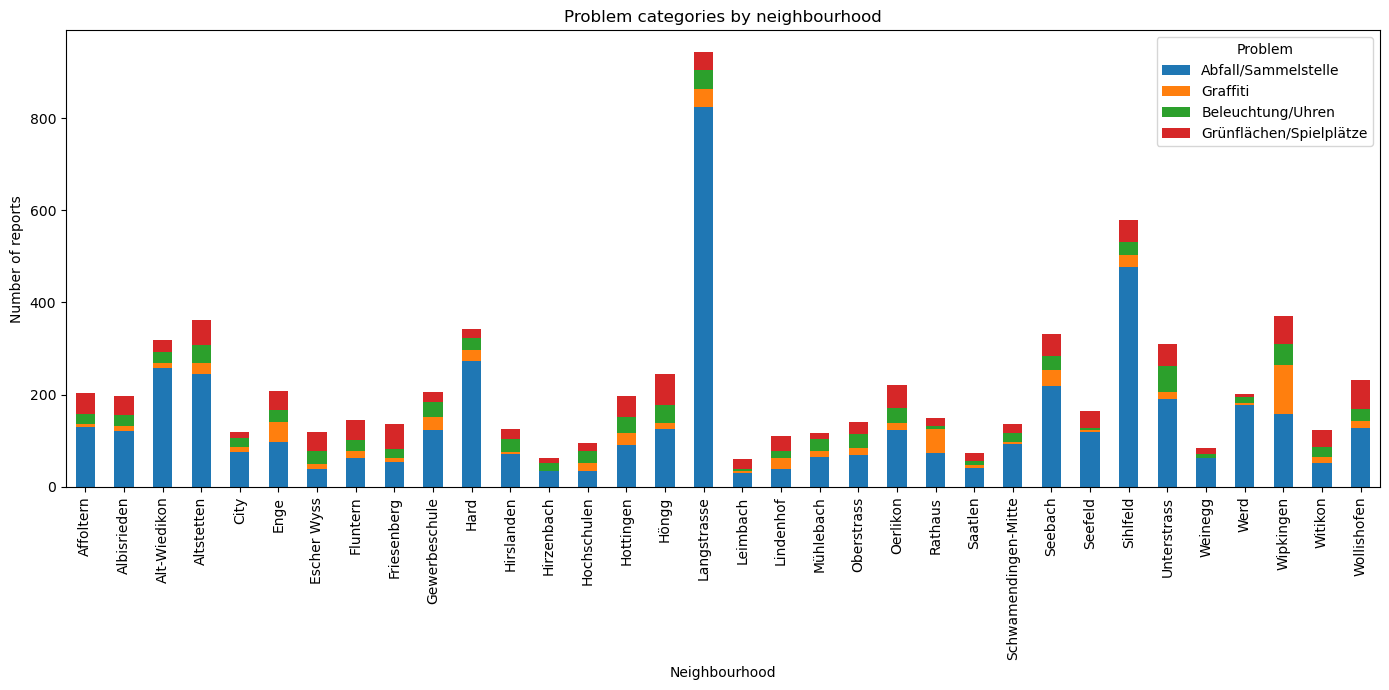

In [122]:
fig, ax = plt.subplots(figsize=(14, 7))

# select problem categories for comparison
selected_categories = category_by_neighbourhood[[
    "Abfall/Sammelstelle",
    "Graffiti",
    "Beleuchtung/Uhren",
    "Grünflächen/Spielplätze"
]]


selected_categories.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title("Problem categories by neighbourhood")
ax.set_xlabel("Neighbourhood")
ax.set_ylabel("Number of reports")

plt.xticks(rotation=90)

ax.legend(title="Problem")

plt.tight_layout()

## save figure
fig.savefig(
    "../outputs/maps/problem_category_by_neighbourhood_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The stacked bar chart highlights differences in the composition of problem categories between neighbourhoods.

It shows that Langstrasse has by far the highest number of reports across all selected categories. Several other neighbourhoods, such as Sihlfeld, Wipkingen, and Altstetten, also show relatively high report counts.

In nearly all neighbourhoods, the category Abfall/Sammelstelle represents the largest share of reports, indicating that waste-related issues dominate the reported infrastructure problems across Zurich. Other categories such as Graffiti, Beleuchtung/Uhren, and Grünflächen/Spielplätze occur less frequently.

## 9. Temporal Analysis
This section analyses how the number of reports changes over time and whether temporal patterns can be observed.

### 9.1. Reports over years
This section analyses how the number of reports changed between 2014 and 2025 in order to identify long-term temporal trends.

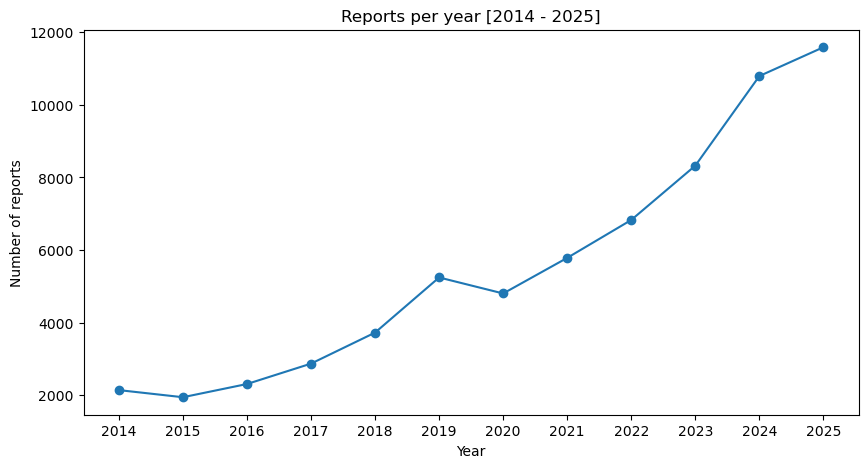

In [124]:
fig, ax = plt.subplots(figsize=(10, 5))

# count reports per year and create line chart
reports_clean.groupby("year").size().plot(
    kind="line",
    marker="o",
    ax=ax
)

ax.set_title("Reports per year [2014 - 2025]")
ax.set_xlabel("Year")
ax.set_ylabel("Number of reports")

# show every year on x-axis
ax.set_xticks(range(2014, 2026))

# save figure
fig.savefig(
    "../outputs/maps/reports_per_year_2014_to_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The number of infrastructure reports shows a clear upward trend between 2014 and 2025. After a slight decline in 2015, report counts increase almost continuously over time. A small decrease can be observed in 2020, followed by particularly strong growth after 2021.

The highest number of reports is observed in 2025, indicating increasing use of the reporting platform and/or a growing number of urban infrastructure problems
### 9.2. Seasonal patterns within the year
This section analyses monthly reporting patterns in 2025 to identify possible seasonal trends.

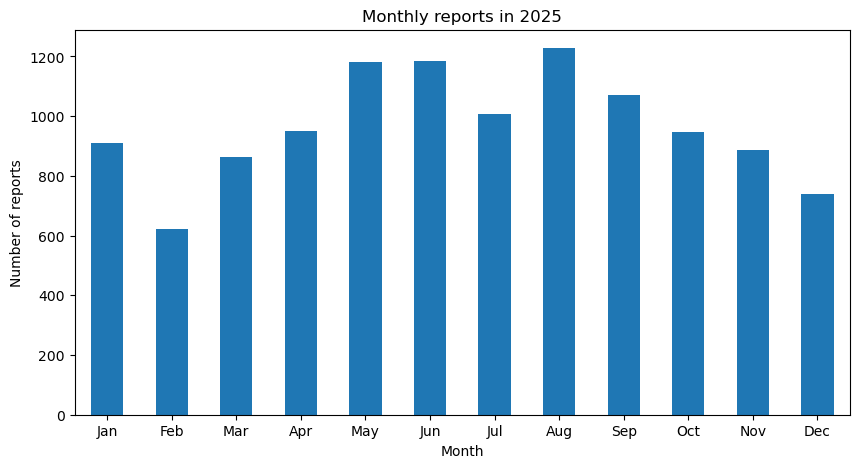

In [126]:
fig, ax = plt.subplots(figsize=(10, 5))

# count reports per month in 2025
monthly_reports = reports_2025.groupby("month").size()

monthly_reports.plot(
    kind="bar",
    ax=ax
)

# create custom month labels for x-axis
month_labels = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

ax.set_title("Monthly reports in 2025")
ax.set_xlabel("Month")
ax.set_ylabel("Number of reports")

ax.set_xticks(range(12))
ax.set_xticklabels(month_labels, rotation=0)

# save figure
fig.savefig(
    "../outputs/maps/monthly_reports_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The monthly distribution shows only moderate seasonal variation in report activity during 2025. The highest numbers of reports occur in May, June, and August, while February has the lowest number of reports. Overall, report counts remain relatively stable throughout the year, although there is a noticeable increase during the late spring and summer months.

### 9.3. Reports by weekday
This analysis examines whether reports are more frequently submitted on certain weekdays.

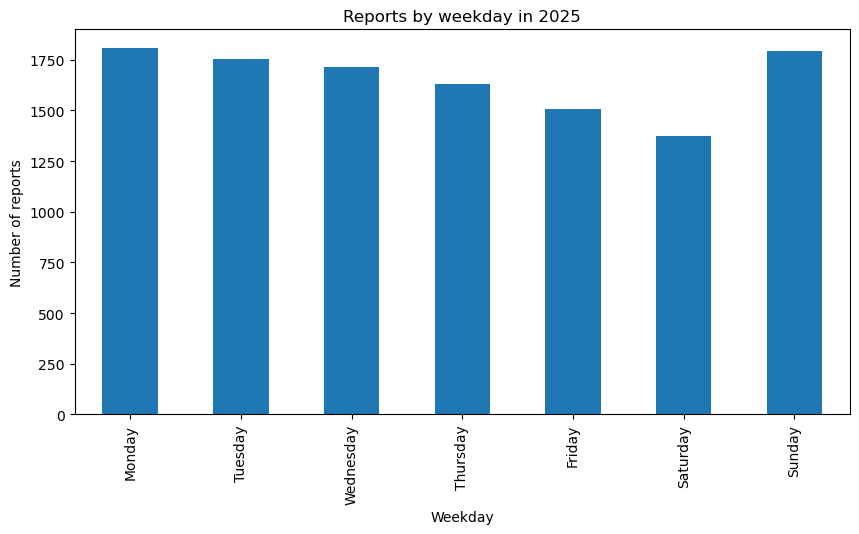

In [127]:
fig, ax = plt.subplots(figsize=(10, 5))

# define correct weekday order
weekday_order = ["Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"]

# count reports per weekday and reorder them
reports_by_weekday = (
    reports_2025["weekday"]
    .value_counts()
    .reindex(weekday_order)
)

reports_by_weekday.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Reports by weekday in 2025")
ax.set_xlabel("Weekday")
ax.set_ylabel("Number of reports")

# save figure
fig.savefig(
    "../outputs/maps/reports_by_weekday_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The number of reports is relatively similar across the weekdays, indicating no strong weekly reporting pattern. Reporting activity gradually decreases from Monday to Saturday, with Saturday showing the lowest number of reports. On Sunday, the number of reports increases again slightly.

## 10. Limitations and possible improvements
**Limitations**

This analysis is based only on reported infrastructure problems and therefore may not reflect all existing issues in Zurich. Reporting activity can also depend on population density, public awareness, or the use of the Züri wie neu platform.
Although the population-normalised analysis improves comparability between neighbourhoods, factors such as commuters, tourists, land use, or infrastructure density are not considered.


**Possible improvements**

Future work could include interactive maps, hotspot analysis, or additional spatial indicators such as land-use data. Further temporal analyses could also examine category-specific seasonal patterns.

## 11. Conclusion
The analysis shows that infrastructure reports in Zurich are unevenly distributed across neighbourhoods. Spatial patterns indicate that central neighbourhoods, particularly Langstrasse and nearby areas, record the highest reporting activity.

After normalising reports by population, the concentration shifts more strongly towards central neighbourhoods such as City and Lindenhof, suggesting that some areas experience disproportionately high reporting intensity relative to their population size.

The categorical analysis revealed that waste-related issues (Abfall/Sammelstelle) are by far the most frequently reported problem category across nearly all neighbourhoods, while categories such as graffiti, lighting, and green spaces occur less frequently.

The temporal analysis demonstrated a strong long-term increase in reports between 2014 and 2025, with only a small decline around 2020. Monthly patterns suggest slightly higher reporting activity during late spring and summer months, while weekday patterns remain relatively stable, with Saturday showing the lowest number of reports.

Overall, the analysis provides useful insights into the spatial, categorical, and temporal distribution of infrastructure problems in Zurich and highlights areas and categories with particularly high reporting activity.